In [1]:
# loading all the required libraries
import pandas as pd
import numpy as np
import torch
from google.colab import files
from itertools import combinations
from collections import Counter
import networkx as nx
from sklearn.model_selection import train_test_split, KFold
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, accuracy_score, confusion_matrix, roc_curve, precision_recall_curve, auc)

In [2]:
# mounting my drive to upload files
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
drugs_se = pd.read_csv("/content/drive/MyDrive/drug_sideeffect_binary_matrix.csv") #reading drugs.tsv file , seperated by tab
drugs_se.head()

# keep only the binary side-effect columns as features
drugs_se = drugs_se.set_index("drug_name")
drugs_se = drugs_se.fillna(0).astype(int)
drugs_se.head()
len(drugs_se.columns)

5599

In [4]:
drug_gene = pd.read_csv("/content/drive/MyDrive/intersection_DGIdb_mat.tsv", sep="\t") #reading drugs.tsv file , seperated by tab
# 1. Name the index 'drug_name'
drug_gene.index.name = 'drug_name'

# 2. Name the columns axis 'gene'
drug_gene.columns.name = 'gene'

# View the result
print(f"drug in Gene file: {drug_gene.index.nunique()}")
drug_gene.head()
len(drug_gene.columns)

drug in Gene file: 777


2022

In [5]:
len(drug_gene.columns)

2022

# **Defining Jaccards similarity Function**

In [6]:
def jaccard_similarity_matrix(binary_df):
    A = binary_df.astype(int).to_numpy()
    inter = A @ A.T
    row_sum = A.sum(axis=1)
    union = row_sum[:, None] + row_sum[None, :] - inter

    sim = np.divide(
        inter, union,
        out=np.zeros_like(inter, dtype=float),
        where=union != 0
    )

    np.fill_diagonal(sim, 1.0)
    return pd.DataFrame(sim, index=binary_df.index, columns=binary_df.index)

In [7]:
# drug-drug similarity based on side-effect profiles
drugse_jaccard = jaccard_similarity_matrix(drugs_se)

# drug-drug similarity based on gene profiles
druggene_jaccard = jaccard_similarity_matrix(drug_gene)

In [8]:
druggene_jaccard.head()

drug_name,ABACAVIR,ABIRATERONE,ACAMPROSATE,ACARBOSE,ACEBUTOLOL,ACETAMINOPHEN,ACETAZOLAMIDE,ACETYLCHOLINE,ACITRETIN,ACLIDINIUM,...,ZALEPLON,ZIDOVUDINE,ZILEUTON,ZIPRASIDONE,ZOLMITRIPTAN,ZOLPIDEM,ZONISAMIDE,ZOPICLONE,ZUCLOPENTHIXOL,PARECOXIB
drug_name,,,,,,,,,,,,,,,,,,,,,
ABACAVIR,1.0,0.0,0.0,0.0,0.0,0.0,0.043478,0.0,0.0,0.0,...,0.0,0.02439,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
ABIRATERONE,0.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.040000,0.0,0.076923,0.0,0.0,0.0,0.0
ACAMPROSATE,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
ACARBOSE,0.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0
ACEBUTOLOL,0.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.0,0.0,0.0,...,0.0,0.00000,0.0,0.045455,0.0,0.000000,0.0,0.0,0.0,0.0


In [9]:
drugse_jaccard.head()

drug_name,2-FLUOROADENOSINE,5-METHYLTETRAHYDROFOLATE,99MTC-CIPROFLOXACIN,ABACAVIR,ABIRATERONE,ACAMPROSATE,ACARBOSE,ACEBUTOLOL,ACENOCOUMAROL,ACETAMINOPHEN,...,ZIDOVUDINE,ZILEUTON,ZINC,ZIPRASIDONE,ZOLEDRONATE,ZOLMITRIPTAN,ZOLPIDEM,ZONISAMIDE,ZOPICLONE,ZUCLOPENTHIXOL
drug_name,,,,,,,,,,,,,,,,,,,,,
2-FLUOROADENOSINE,1.000000,0.000000,0.156997,0.232653,0.139423,0.219136,0.077720,0.193548,0.071823,0.177258,...,0.239437,0.129534,0.000000,0.147303,0.202417,0.180055,0.157647,0.198347,0.154891,0.152597
5-METHYLTETRAHYDROFOLATE,0.000000,1.000000,0.000000,0.007353,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.005376,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
99MTC-CIPROFLOXACIN,0.156997,0.000000,1.000000,0.153025,0.093809,0.271012,0.055238,0.158845,0.032505,0.205527,...,0.220280,0.076336,0.001946,0.271570,0.237937,0.259380,0.277439,0.263754,0.231629,0.188136
ABACAVIR,0.232653,0.007353,0.153025,1.000000,0.169492,0.220736,0.105590,0.242991,0.071895,0.201493,...,0.282869,0.160494,0.007246,0.146930,0.218543,0.185629,0.175573,0.223565,0.172107,0.177536
ABIRATERONE,0.139423,0.000000,0.093809,0.169492,1.000000,0.145038,0.086538,0.168605,0.064516,0.142222,...,0.142222,0.149533,0.000000,0.098321,0.160920,0.125850,0.144092,0.122112,0.081967,0.135371


# Merging NA and NB using drug_gene similarity matrix on drugs and connected their associated gene and se with similarity score. Additionally, drugs showing similarity above 0.5 (threshold) is also added to the table.

* only keeps drugs passing the drug-gene similarity >= 0.3 threshold
* removes self-similarity
* uses common drugs only
* no duplication



In [10]:
# =========================================================
# 1) REMOVE AXIS NAMES (avoids duplication issues)
# =========================================================

druggene_jaccard.index.name = None
druggene_jaccard.columns.name = None

drugse_jaccard.index.name = None
drugse_jaccard.columns.name = None

drug_gene.index.name = None
drug_gene.columns.name = None

drugs_se.index.name = None
drugs_se.columns.name = None

# =========================================================
# 2) KEEP COMMON DRUGS ONLY
# =========================================================

common_drugs = (
    druggene_jaccard.index
    .intersection(drugse_jaccard.index)
    .intersection(drug_gene.index)
    .intersection(drugs_se.index))

# Filter matrices
dg_sim = druggene_jaccard.loc[common_drugs, common_drugs]
se_sim = drugse_jaccard.loc[common_drugs, common_drugs]

# =========================================================
# 3) CREATE FINAL TABLE
#    KEEP ONLY DRUGS HAVING
#    DRUG-GENE SIMILARITY >= 0.5
# =========================================================

rows = []

for drug in dg_sim.index:

    # remove self similarity
    gene_scores = dg_sim.loc[drug].drop(labels=[drug], errors='ignore')

    # keep only similarity >= 0.5
    gene_scores = gene_scores[gene_scores >= 0.3]

    # skip drugs not passing threshold
    if len(gene_scores) == 0:
        continue

    # -----------------------------------------------------
    # Associated genes
    # -----------------------------------------------------
    associated_genes = drug_gene.columns[
        drug_gene.loc[drug] == 1
    ].tolist()

    # -----------------------------------------------------
    # Associated side effects
    # -----------------------------------------------------
    associated_side_effects = drugs_se.columns[
        drugs_se.loc[drug] == 1
    ].tolist()

    # -----------------------------------------------------
    # Similar drugs + scores
    # -----------------------------------------------------
    similar_gene_drugs = gene_scores.index.tolist()
    gene_similarity_scores = gene_scores.values.tolist()

    # -----------------------------------------------------
    # Side-effect similarity scores
    # (for same similar drugs)
    # -----------------------------------------------------
    se_scores = []

    for sim_drug in similar_gene_drugs:

        if sim_drug in se_sim.columns:
            se_score = se_sim.loc[drug, sim_drug]
        else:
            se_score = np.nan

        se_scores.append(se_score)

    # -----------------------------------------------------
    # Store row
    # -----------------------------------------------------
    rows.append({
        'drug_name': drug,
        'similar_drugs': similar_gene_drugs,
        'drug_gene_similarity_scores': gene_similarity_scores,
        'drug_se_similarity_scores': se_scores,
        'associated_genes': associated_genes,
        'associated_side_effects': associated_side_effects
    })

# =========================================================
# 4) FINAL DATAFRAME
# =========================================================

common_df = pd.DataFrame(rows)

# =========================================================
# 5) VIEW RESULTS
# =========================================================

print("\nFinal shape:")
print(common_df.shape)
common_df.head() # saves drug name, similar drug, assocaited genes and se


Final shape:
(536, 6)


,drug_name,similar_drugs,drug_gene_similarity_scores,drug_se_similarity_scores,associated_genes,associated_side_effects
0,ACAMPROSATE,[MEMANTINE],[0.3333333333333333],[0.3150684931506849],"[GRIN2B, GRIN3A, GRM5]","[ABDOMINAL DISTENSION, ABDOMINAL PAIN, ABNORMA..."
1,ACARBOSE,[MIGLITOL],[0.42857142857142855],[0.4772727272727273],"[AMY2A, GAA, LPL, MGA, MGAM, SI, SLC2A4]","[ABDOMINAL PAIN, ANGIOPATHY, CONSTIPATION, DER..."
2,ACEBUTOLOL,"[BETAXOLOL, BISOPROLOL, BRETYLIUM, CARTEOLOL, ...","[0.3333333333333333, 0.3333333333333333, 0.5, ...","[0.3187919463087248, 0.3779527559055118, 0.176...","[ADRB1, TG]","[ABDOMINAL PAIN, ABNORMAL DREAMS, ABNORMAL VIS..."
3,ACETAZOLAMIDE,"[BRINZOLAMIDE, METHAZOLAMIDE]","[0.38461538461538464, 0.375]","[0.09917355371900827, 0.5833333333333334]","[AQP1, AQP4, CA1, CA12, CA14, CA2, CA3, CA4, C...","[AGITATION, AGRANULOCYTOSIS, ANAPHYLACTIC SHOC..."
4,ACETYLCHOLINE,"[ACLIDINIUM, ATROPINE, BETHANECHOL, CARBACHOL,...","[0.8333333333333334, 0.38461538461538464, 0.83...","[0.0, 0.02843601895734597, 0.10526315789473684...","[ACE, CHRM1, CHRM2, CHRM3, CHRM4, CHRM5]","[BRADYCARDIA, CORNEAL DECOMPENSATION, CORNEAL ..."


In [11]:
common_df[common_df["drug_name"] == "ACARBOSE"] # BY SEARCHING DRUG NAME WE CAN GET TO KNOW ABOUT IT'S METRICES.

,drug_name,similar_drugs,drug_gene_similarity_scores,drug_se_similarity_scores,associated_genes,associated_side_effects
1,ACARBOSE,[MIGLITOL],[0.42857142857142855],[0.4772727272727273],"[AMY2A, GAA, LPL, MGA, MGAM, SI, SLC2A4]","[ABDOMINAL PAIN, ANGIOPATHY, CONSTIPATION, DER..."


TO IDENTIFY THE DRUGS DIRECTLY BASED ON ASSOCIATED SIDE EFFECTS

In [12]:
common_df[common_df["associated_side_effects"].apply(lambda x: "DERMATITIS" in str(x))]

,drug_name,similar_drugs,drug_gene_similarity_scores,drug_se_similarity_scores,associated_genes,associated_side_effects
0,ACAMPROSATE,[MEMANTINE],[0.3333333333333333],[0.3150684931506849],"[GRIN2B, GRIN3A, GRM5]","[ABDOMINAL DISTENSION, ABDOMINAL PAIN, ABNORMA..."
1,ACARBOSE,[MIGLITOL],[0.42857142857142855],[0.4772727272727273],"[AMY2A, GAA, LPL, MGA, MGAM, SI, SLC2A4]","[ABDOMINAL PAIN, ANGIOPATHY, CONSTIPATION, DER..."
2,ACEBUTOLOL,"[BETAXOLOL, BISOPROLOL, BRETYLIUM, CARTEOLOL, ...","[0.3333333333333333, 0.3333333333333333, 0.5, ...","[0.3187919463087248, 0.3779527559055118, 0.176...","[ADRB1, TG]","[ABDOMINAL PAIN, ABNORMAL DREAMS, ABNORMAL VIS..."
5,ACITRETIN,[ADAPALENE],[0.4375],[0.07523510971786834],"[GMNN, IL1B, KAT2A, KDM4A, MAPT, PLK1, RAPGEF4...","[ABDOMINAL PAIN, ACNE, ACUTE MYOCARDIAL INFARC..."
7,ADAPALENE,"[ACITRETIN, BEXAROTENE, TAZAROTENE]","[0.4375, 0.3076923076923077, 0.36363636363636365]","[0.07523510971786834, 0.06441717791411043, 0.2...","[RARA, RARB, RARG, RXRA, RXRB, RXRG, USP1]","[ABRASION NOS, ANGIOEDEMA, APPLICATION SITE PA..."
...,...,...,...,...,...,...
531,ZOLPIDEM,"[FLUNITRAZEPAM, GRISEOFULVIN, ZOPICLONE]","[0.38461538461538464, 0.3, 0.4]","[0.10810810810810811, 0.06784660766961652, 0.3...","[AR, CYP3A4, CYP3A5, GABRA1, GABRA2, GABRA3, G...","[ABDOMINAL DISCOMFORT, ABDOMINAL PAIN, ABDOMIN..."
532,ZONISAMIDE,"[ETHOTOIN, LAMOTRIGINE, LIDOCAINE, MEPHENYTOIN...","[0.43478260869565216, 0.32432432432432434, 0.3...","[0.06859205776173286, 0.4228187919463087, 0.15...","[AQP4, CA1, CA12, CA7, CACNA1G, CACNA1H, CACNA...","[ABDOMINAL PAIN, ABNORMAL DREAMS, ACCIDENTAL I..."
533,ZOPICLONE,"[BUTABARBITAL, FLUNITRAZEPAM, SECOBARBITAL, ZO...","[0.36363636363636365, 0.5555555555555556, 0.36...","[0.08487084870848709, 0.11439114391143912, 0.0...","[GABRA1, GABRA2, GABRA3, GABRA5, TSPO]","[ABDOMINAL PAIN, ABNORMAL BEHAVIOUR, ABNORMAL ..."
534,ZUCLOPENTHIXOL,"[FLUPHENAZINE, ISOXSUPRINE, KETOTIFEN, NAPHAZO...","[0.3333333333333333, 0.4, 0.3333333333333333, ...","[0.2170212765957447, 0.03553299492385787, 0.12...","[CYP1A2, CYP2D6, DRD1, DRD2, DRD5]","[ABDOMINAL PAIN, ABNORMAL DREAMS, ABNORMAL VIS..."


# **Building Drug Similarity graph from common df**
Use the thresholded common_df (where only drugs with at least one gene similarity ≥ 0.5 are kept in the graph and everything else is removed.) for the graph, not the full common_drugs intersection. **(NOT TO DELETE)**

In [13]:
# G = nx.Graph()

# seen_edges = set()

# for _, row in common_df.iterrows():
#     drug = row["drug_name"]
#     genes = row["associated_genes"]
#     side_effects = row["associated_side_effects"]

#     # Add the main drug node
#     G.add_node(
#         drug,
#         genes=genes,
#         side_effects=side_effects
#     )

#     similar_drugs = row["similar_drugs"]
#     gene_scores = row["drug_gene_similarity_scores"]
#     se_scores = row["drug_se_similarity_scores"]

#     for sim_drug, gene_score, se_score in zip(similar_drugs, gene_scores, se_scores):

#         # avoid duplicate undirected edges
#         edge_key = tuple(sorted((drug, sim_drug)))
#         if edge_key in seen_edges:
#             continue

#         seen_edges.add(edge_key)

#         # add similar drug node if not already present
#         if sim_drug not in G:
#             G.add_node(sim_drug)

#         # add edge with both similarity scores
#         G.add_edge(
#             drug,
#             sim_drug,
#             drug_gene_similarity=gene_score,
#             drug_se_similarity=se_score
#         )

# print("Number of nodes:", G.number_of_nodes())
# print("Number of edges:", G.number_of_edges())

COMMON DRUGS FROM BOTH THE SIMILARITY MATTRIX, HAVING THRESHOLD OF 0.5 DRUG-GENE SIMILARITY SCORE, AND THEIR ASSOCIATED SIDE-EFFECTS.
DRUGS ARE CONNECTED TO THE DRUGS WHICH SHOWS SIMILARITY. **(NOT TO DELETE)**

In [14]:
# plt.figure(figsize=(14, 10))
# pos = nx.spring_layout(G, k=0.5)

# nx.draw_networkx_nodes(G, pos, node_size=400, alpha=0.8)
# nx.draw_networkx_edges(G, pos, alpha=0.3)
# #nx.draw_networkx_labels(G, pos, font_size=8)

# plt.title("Common Drug Graph: shared structure in SE and Gene networks")
# plt.axis("off")
# plt.show()

Here the common df has 563 drugs same as chunk 8, and not as above graph which shows only 308 after applying threshold for graphical purpose.

In [15]:
# =========================================================
# 1) DRUGS FROM YOUR UPDATED common_df
# =========================================================

common_drugs = common_df["drug_name"].drop_duplicates().tolist()

# Keep only drugs present in both matrices
common_drugs = (
    pd.Index(common_drugs)
    .intersection(druggene_jaccard.index)
    .intersection(drugs_se.index)
    .tolist()
)

print("Number of usable drugs:", len(common_drugs))

# =========================================================
# 2) FILTER MATRICES
# =========================================================

drug_gene_sim = druggene_jaccard.loc[common_drugs, common_drugs]
drug_se_matrix = drugs_se.loc[common_drugs]

W = drug_gene_sim.to_numpy(dtype=float)

print("Similarity matrix shape:", W.shape)
print("Side-effect matrix shape:", drug_se_matrix.shape)

# =========================================================
# 3) HARMONIC FUNCTION PREDICTION
# =========================================================

def harmonic_prediction(W, y, train_idx, eps=1e-6):
    """
    W: similarity matrix
    y: binary label vector for one side effect
    train_idx: indices of labeled training drugs
    """
    W = W.astype(float).copy()
    np.fill_diagonal(W, 0.0)

    d = W.sum(axis=1)
    L = np.diag(d) - W

    all_idx = np.arange(W.shape[0])
    unlabeled_idx = np.setdiff1d(all_idx, train_idx)

    L_uu = L[np.ix_(unlabeled_idx, unlabeled_idx)]
    L_ul = L[np.ix_(unlabeled_idx, train_idx)]

    f_u = np.linalg.solve(
        L_uu + eps * np.eye(L_uu.shape[0]),
        -L_ul @ y[train_idx]
    )

    f = np.zeros(W.shape[0], dtype=float)
    f[train_idx] = y[train_idx]
    f[unlabeled_idx] = f_u

    return f

def minmax_scale(x):
    x = np.asarray(x, dtype=float)
    return (x - x.min()) / (x.max() - x.min() + 1e-12)

# =========================================================
# 4) 5-FOLD CROSS VALIDATION SPLIT ON DRUGS
# =========================================================

kf = KFold(n_splits=5, shuffle=True, random_state=27)

results = []

for fold, (train_idx, test_idx) in enumerate(kf.split(common_drugs), start=1):

    print(f"\nProcessing fold {fold}...")
    print("Train drugs:", len(train_idx), "Test drugs:", len(test_idx))

    for side_effect in drug_se_matrix.columns:

        y = drug_se_matrix[side_effect].to_numpy(dtype=float)

        y_train = y[train_idx]
        y_test = y[test_idx]

        if y_train.sum() == 0 or y_test.sum() == 0:
            continue

        if len(np.unique(y_test)) < 2:
            continue

        # harmonic prediction
        scores = harmonic_prediction(W, y, train_idx)

        y_score = scores[test_idx]
        y_score_norm = minmax_scale(y_score)
        y_pred = (y_score_norm >= 0.5).astype(int)


        # metrics
        auroc = roc_auc_score(y_test, y_score)
        auprc = average_precision_score(y_test, y_score)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        specificity = tn / (tn + fp + 1e-12)

        results.append({
            "fold": fold,
            "side_effect": side_effect,
            "AUC_ROC": auroc,
            "AUPRC": auprc,
            "Precision": precision,
            "Recall": recall,
            "F1_Score": f1,
            "Specificity": specificity,
            "Accuracy": accuracy,
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        })

# =========================================================
# 5) RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(results)

print("\nResults head:")
print(results_df.head())

print("\nResults shape:")
print(results_df.shape)

# =========================================================
# 6) FOLD-WISE SUMMARY
# =========================================================

fold_summary = (
    results_df
    .groupby("fold")[["AUC_ROC", "AUPRC", "Precision", "Recall", "F1_Score", "Specificity", "Accuracy"]]
    .mean()
    .reset_index()
)

print("\nFold-wise mean performance:")
print(fold_summary)

# =========================================================
# 7) OVERALL SUMMARY
# =========================================================

overall_summary = (
    results_df[["AUC_ROC", "AUPRC", "Precision", "Recall", "F1_Score", "Specificity", "Accuracy"]]
    .mean()
)

print("\nOverall mean performance across all folds:")
print(overall_summary)
# print("\nNumber of evaluated side effects:", results_df.shape[0])

# =========================================================
# 8) SIDE EFFECT PERFORMANCE SUMMARY
# =========================================================

side_effect_summary = (
    results_df
    .groupby("side_effect")
    .agg({
        "AUC_ROC": ["mean", "std"],
        "AUPRC": ["mean", "std"],
        "Precision": ["mean", "std"],
        "Recall": ["mean", "std"],
        "F1_Score": ["mean", "std"],
        "Specificity": ["mean", "std"],
        "Accuracy": ["mean", "std"]
    })
)

side_effect_summary.columns = [
    "_".join(col)
    for col in side_effect_summary.columns
]

side_effect_summary = (
    side_effect_summary
    .reset_index()
)


# =========================================================
# 9) RANK USING AUPRC
# =========================================================

side_effect_summary = (
    side_effect_summary
    .sort_values(
        by="AUPRC_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

side_effect_summary["Rank"] = (
    side_effect_summary.index + 1
)


# =========================================================
# 10) FINAL RESULTS
# =========================================================

final_ranked_results = (
    side_effect_summary.copy()
)


# =========================================================
# 11) MEAN ± SD FORMAT
# =========================================================

final_ranked_results["AUPRC"] = (
    final_ranked_results["AUPRC_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["AUPRC_std"].round(3).astype(str)
)

final_ranked_results["AUROC"] = (
    final_ranked_results["AUC_ROC_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["AUC_ROC_std"].round(3).astype(str)
)

final_ranked_results["Precision"] = (
    final_ranked_results["Precision_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Precision_std"].round(3).astype(str)
)

final_ranked_results["Recall"] = (
    final_ranked_results["Recall_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Recall_std"].round(3).astype(str)
)

final_ranked_results["F1"] = (
    final_ranked_results["F1_Score_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["F1_Score_std"].round(3).astype(str)
)

final_ranked_results["Specificity"] = (
    final_ranked_results["Specificity_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Specificity_std"].round(3).astype(str)
)

final_ranked_results["Accuracy"] = (
    final_ranked_results["Accuracy_mean"].round(3).astype(str)
    + " ± " +
    final_ranked_results["Accuracy_std"].round(3).astype(str)
)


# =========================================================
# 12) FINAL PAPER TABLE
# =========================================================

paper_table = (
    final_ranked_results[
        [
            "Rank",
            "side_effect",
            "AUPRC",
            "AUROC",
            "Precision",
            "Recall",
            "F1",
            "Specificity",
            "Accuracy"
        ]
    ]
    .copy()
)

Number of usable drugs: 536
Similarity matrix shape: (536, 536)
Side-effect matrix shape: (536, 5599)

Processing fold 1...
Train drugs: 428 Test drugs: 108

Processing fold 2...
Train drugs: 429 Test drugs: 107

Processing fold 3...
Train drugs: 429 Test drugs: 107

Processing fold 4...
Train drugs: 429 Test drugs: 107

Processing fold 5...
Train drugs: 429 Test drugs: 107

Results head:
   fold           side_effect   AUC_ROC     AUPRC  Precision    Recall  \
0     1    ABDOMINAL BLOATING  0.627298  0.194505   0.222222  0.285714   
1     1       ABDOMINAL COLIC  0.834906  0.077031   0.000000  0.000000   
2     1      ABDOMINAL CRAMPS  0.850485  0.324099   0.500000  0.200000   
3     1  ABDOMINAL DISCOMFORT  0.595919  0.352587   0.500000  0.038462   
4     1  ABDOMINAL DISTENSION  0.528578  0.297870   0.261905  0.407407   

   F1_Score  Specificity  Accuracy  TP   TN  FP  FN  
0  0.250000     0.930693  0.888889   2   94   7   5  
1  0.000000     0.943396  0.925926   0  100   6   2  
2

In [16]:
print("\nTop Ranked Side Effects (AUPRC Ranking)")
display(paper_table.head(10))


Top Ranked Side Effects (AUPRC Ranking)


,Rank,side_effect,AUPRC,AUROC,Precision,Recall,F1,Specificity,Accuracy
0,1,CONTACT LENS INTOLERANCE,1.0 ± 0.0,1.0 ± 0.0,0.667 ± 0.471,1.0 ± 0.0,0.75 ± 0.354,0.991 ± 0.013,0.991 ± 0.013
1,2,NODAL BLOCK,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
2,3,COMPULSIONS,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
3,4,NECROTIZING ENTEROCOLITIS,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
4,5,NECROTISING ENTEROCOLITIS NEONATAL,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
5,6,NECROTISING COLITIS,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
6,7,ORAL PRURITUS,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007
7,8,OESTROGENIC EFFECT,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
8,9,GENITAL INFECTION FUNGAL,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0,1.0 ± 0.0
9,10,GENITAL DISCHARGE,1.0 ± 0.0,1.0 ± 0.0,0.75 ± 0.354,1.0 ± 0.0,0.833 ± 0.236,0.995 ± 0.007,0.995 ± 0.007


In [17]:
print("\nBottom Ranked Side Effects (AUPRC Ranking)")
display(paper_table.tail(10))


Bottom Ranked Side Effects (AUPRC Ranking)


,Rank,side_effect,AUPRC,AUROC,Precision,Recall,F1,Specificity,Accuracy
2742,2743,VASOCONSTRICTION PERIPHERAL,0.009 ± 0.0,0.252 ± 0.337,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.013,0.963 ± 0.013
2743,2744,VASOCONSTRICTION,0.009 ± 0.0,0.252 ± 0.337,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.013,0.963 ± 0.013
2744,2745,PANCREATITIS NECROTISING,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.991 ± 0.013,0.981 ± 0.013
2745,2746,OCULAR STINGING,0.009 ± 0.0,0.257 ± 0.344,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.986 ± 0.02,0.977 ± 0.02
2746,2747,BLOOD PHOSPHORUS INCREASED,0.009 ± 0.0,0.255 ± 0.347,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.981 ± 0.027,0.972 ± 0.026
2747,2748,BONE DENSITY DECREASED,0.009 ± 0.0,0.262 ± 0.33,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.986 ± 0.007,0.977 ± 0.006
2748,2749,CORNEAL ABRASION,0.009 ± 0.0,0.257 ± 0.344,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.986 ± 0.02,0.977 ± 0.02
2749,2750,PITUITARY TUMOUR BENIGN,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.04,0.963 ± 0.039
2750,2751,BREAST ATROPHY,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.771 ± 0.324,0.764 ± 0.321
2751,2752,PITUITARY ADENOMA,0.009 ± 0.0,0.264 ± 0.334,0.0 ± 0.0,0.0 ± 0.0,0.0 ± 0.0,0.972 ± 0.04,0.963 ± 0.039


In [18]:
fold_summary.head()

,fold,AUC_ROC,AUPRC,Precision,Recall,F1_Score,Specificity,Accuracy
0,1,0.685208,0.216156,0.165883,0.211601,0.146281,0.928579,0.900552
1,2,0.667461,0.233446,0.206260,0.215191,0.164594,0.924052,0.898041
2,3,0.661679,0.210914,0.159062,0.211017,0.146667,0.922990,0.895957
3,4,0.668137,0.191796,0.150969,0.186388,0.127720,0.926703,0.898850
4,5,0.668190,0.197018,0.131555,0.201564,0.129155,0.919505,0.894320


In [19]:
overall_summary.head(10)

,0
AUC_ROC,0.670215
AUPRC,0.210628
Precision,0.164252
Recall,0.205457
F1_Score,0.143605
Specificity,0.924478
Accuracy,0.897635


Figures and plots

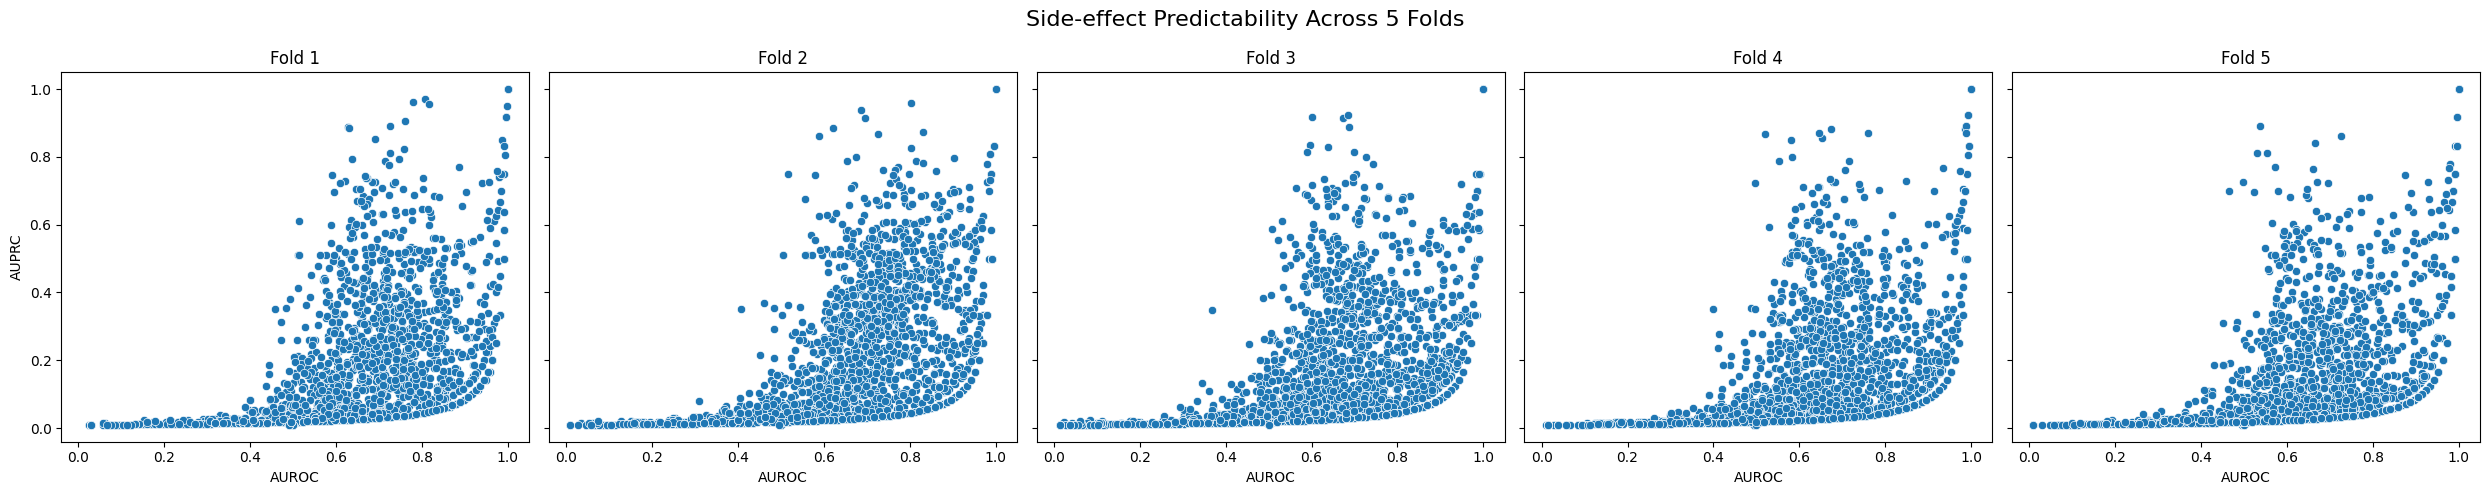

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5), sharex=True, sharey=True)

for i, fold_num in enumerate([1, 2, 3, 4, 5]):

    fold_data = results_df[
        results_df["fold"] == fold_num
    ]

    sns.scatterplot(
        data=fold_data,
        x="AUC_ROC",
        y="AUPRC",
        ax=axes[i]
    )

    axes[i].set_title(f"Fold {fold_num}")

    axes[i].set_xlabel("AUROC")
    axes[i].set_ylabel("AUPRC")

plt.suptitle(
    "Side-effect Predictability Across 5 Folds",
    fontsize=16
)

plt.tight_layout()

plt.show()

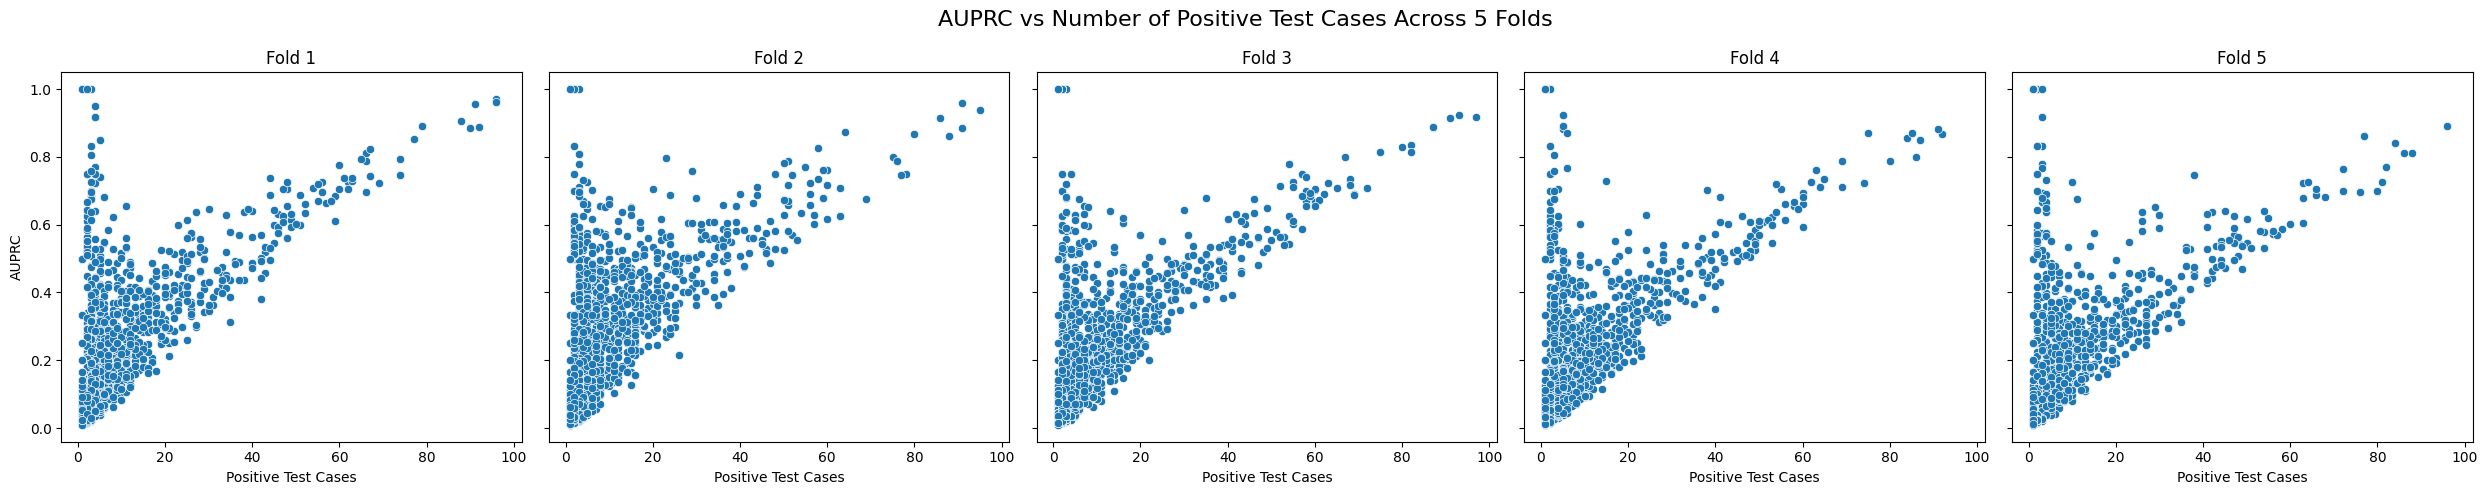

In [21]:
# Create prevalence column
results_df["test_prevalence"] = (
    results_df["TP"] + results_df["FN"]
)

# =========================================================
# SIDE-BY-SIDE SCATTER PLOTS FOR EACH FOLD
# =========================================================

fig, axes = plt.subplots(
    1, 5,
    figsize=(25, 5),
    sharex=True,
    sharey=True
)

for i, fold_num in enumerate([1, 2, 3, 4, 5]):

    fold_data = results_df[
        results_df["fold"] == fold_num
    ]

    sns.scatterplot(
        data=fold_data,
        x="test_prevalence",
        y="AUPRC",
        ax=axes[i]
    )

    axes[i].set_title(f"Fold {fold_num}")

    axes[i].set_xlabel("Positive Test Cases")
    axes[i].set_ylabel("AUPRC")

plt.suptitle(
    "AUPRC vs Number of Positive Test Cases Across 5 Folds",
    fontsize=16
)

plt.tight_layout()

plt.show()

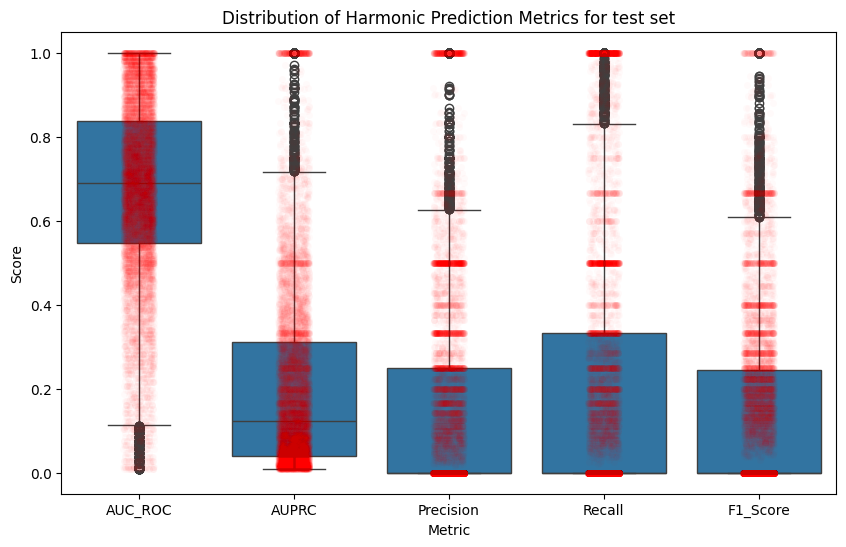

In [22]:
# Select metrics
plot_df = results_df[[
    "AUC_ROC",
    "AUPRC",
    "Precision",
    "Recall",
    "F1_Score"
]]

# Convert wide → long format
plot_df = plot_df.melt(
    var_name="Metric",
    value_name="Score"
)

# Figure
plt.figure(figsize=(10, 6))

# Boxplot
sns.boxplot(
    data=plot_df,
    x="Metric",
    y="Score"
)

# Stripplot
sns.stripplot(
    data=plot_df,
    x="Metric",
    y="Score",
    color="red",
    alpha=0.02,
    jitter=True
)

# Title
plt.title("Distribution of Harmonic Prediction Metrics for test set")

# Rotate labels
#plt.xticks(rotation=30)

plt.show()

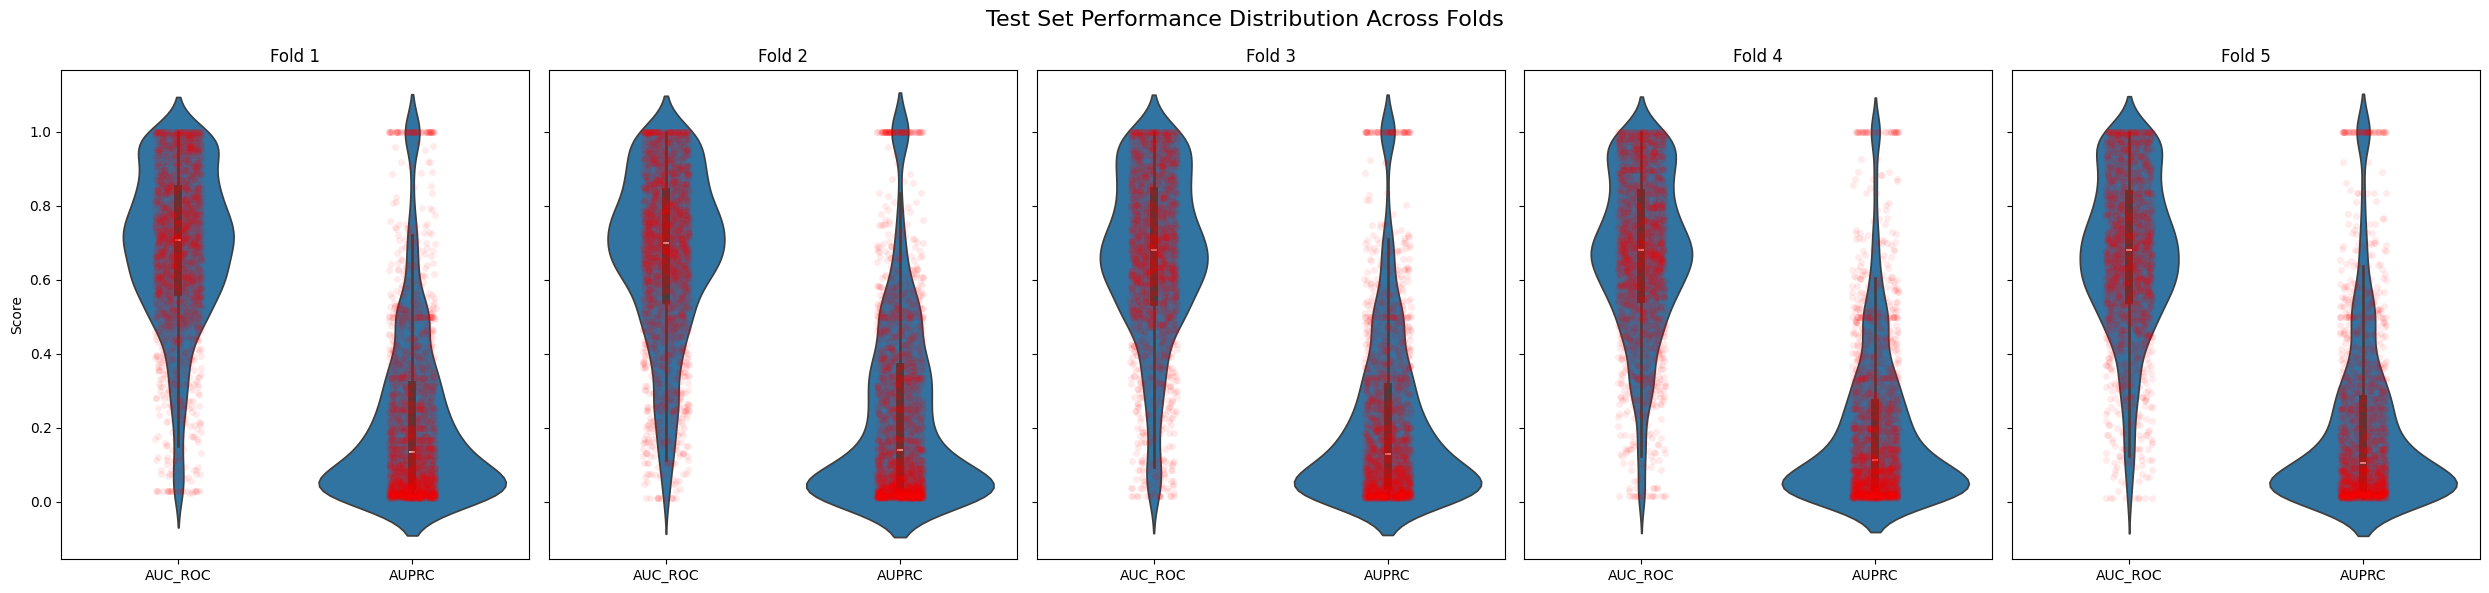

In [23]:
# =========================================================
# VIOLIN + STRIP PLOT FOR EACH FOLD
# =========================================================

fig, axes = plt.subplots(1, 5, figsize=(25, 6), sharey=True)

for i, fold_num in enumerate([1, 2, 3, 4, 5]):

    fold_df = results_df[results_df["fold"] == fold_num]

    plot_df = fold_df[[
        "AUC_ROC",
        "AUPRC"
    ]].melt(
        var_name="Metric",
        value_name="Score"
    )

    sns.violinplot(
        data=plot_df,
        x="Metric",
        y="Score",
        inner="box",
        ax=axes[i]
    )

    sns.stripplot(
        data=plot_df,
        x="Metric",
        y="Score",
        color="red",
        alpha=0.08,
        jitter=True,
        ax=axes[i]
    )

    axes[i].set_title(f"Fold {fold_num}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Score" if i == 0 else "")

plt.suptitle("Test Set Performance Distribution Across Folds", fontsize=16)
plt.tight_layout()
plt.show()

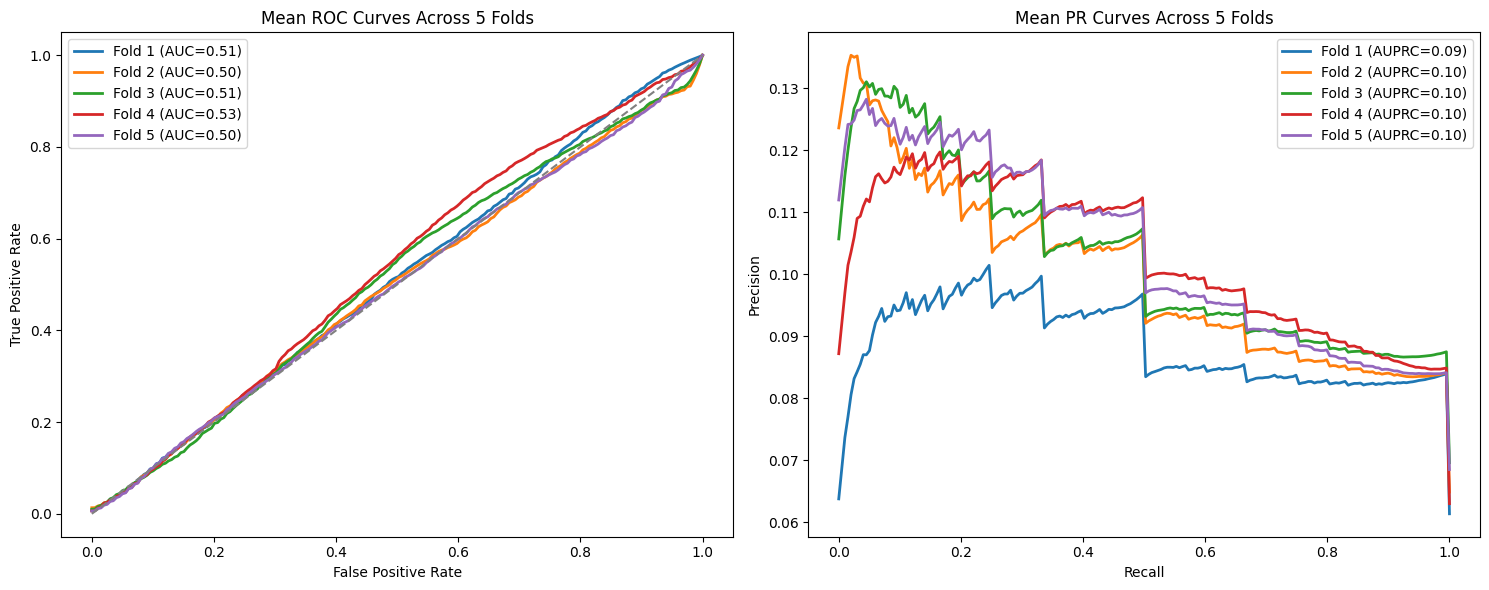

In [24]:
W = drug_gene_sim.to_numpy(dtype=float)
side_effects_to_use = results_df["side_effect"].drop_duplicates().tolist()

roc_grid = np.linspace(0, 1, 200)
pr_grid = np.linspace(0, 1, 200)

kf = KFold(n_splits=5, shuffle=True, random_state=27)

fold_curves = {}

for fold_num, (train_idx, test_idx) in enumerate(kf.split(common_drugs), start=1):

    fold_tprs = []
    fold_precs = []
    fold_aucs = []
    fold_auprcs = []

    for side_effect_name in side_effects_to_use:

        y = drugs_se[side_effect_name].to_numpy(dtype=float)

        y_true_test = y[test_idx]

        # skip invalid folds for this side effect
        if y[test_idx].sum() == 0 or y[test_idx].sum() == len(test_idx):
            continue

        if len(np.unique(y_true_test)) < 2:
            continue

        # harmonic prediction scores
        scores = harmonic_prediction(W, y, train_idx)

        y_score_test = scores[test_idx]

        # ROC
        fpr_te, tpr_te, _ = roc_curve(y_true_test, y_score_test)

        # PR
        prec_te, rec_te, _ = precision_recall_curve(y_true_test, y_score_test)

        # Interpolate to common grids
        fold_tprs.append(np.interp(roc_grid, fpr_te, tpr_te))
        fold_precs.append(np.interp(pr_grid, rec_te[::-1], prec_te[::-1]))

        # Store fold-level summary scores
        fold_aucs.append(auc(fpr_te, tpr_te))
        fold_auprcs.append(average_precision_score(y_true_test, y_score_test))

    if len(fold_tprs) == 0:
        continue

    fold_curves[fold_num] = {
        "mean_tpr": np.mean(fold_tprs, axis=0),
        "std_tpr": np.std(fold_tprs, axis=0),
        "mean_prec": np.mean(fold_precs, axis=0),
        "std_prec": np.std(fold_precs, axis=0),
        "mean_auc": float(np.mean(fold_aucs)),
        "mean_auprc": float(np.mean(fold_auprcs))
    }

# ---------------------------------------------------------
# PLOT ALL FOLDS ON THE SAME GRAPH
# ---------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC curves
for fold_num, data in fold_curves.items():
    axes[0].plot(
        roc_grid,
        data["mean_tpr"],
        linewidth=2,
        label=f"Fold {fold_num} (AUC={data['mean_auc']:.2f})"
    )

axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_title("Mean ROC Curves Across 5 Folds")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# PR curves
for fold_num, data in fold_curves.items():
    axes[1].plot(
        pr_grid,
        data["mean_prec"],
        linewidth=2,
        label=f"Fold {fold_num} (AUPRC={data['mean_auprc']:.2f})"
    )

axes[1].set_title("Mean PR Curves Across 5 Folds")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

main file ends above.

**this is experimental to get access of desired adr, associated drugs, genes and respective weighted similarity score.**

Predicted ADR (DERMATITIS) → Associated Drugs → Associated Genes → Similarity Strength

In [66]:
ranked_se_interpretor = common_df[  # Getting all selected se drugs
    common_df["associated_side_effects"]
    .apply(lambda x: "BALANITIS CANDIDA" in str(x))
].copy()


ranked_se_interpretor["mean_drug_se_score"] = ( #drug_se_similarity_score is a list, converting it into single score
    ranked_se_interpretor["drug_se_similarity_scores"]
    .apply(lambda x: np.mean(x) if isinstance(x, list) else x)
)

se_ranked = (  #rank drugs
    ranked_se_interpretor
    .sort_values(
        "mean_drug_se_score",
        ascending=False
    )
)

se_ranked_final = se_ranked[
    [
        "drug_name",
        "associated_genes",
        "mean_drug_se_score"
    ]
]
se_ranked_final.head()


,drug_name,associated_genes,mean_drug_se_score
73,CANAGLIFLOZIN,"[SLC5A1, SLC5A4]",0.312057
122,DAPAGLIFLOZIN,"[SLC5A1, SLC5A2, SLC5A4]",0.312057


In [67]:
from collections import Counter

gene_counter = Counter()

for genes in se_ranked_final["associated_genes"]:

    if isinstance(genes, list):
        gene_counter.update(genes)

gene_freq_df = pd.DataFrame(
    gene_counter.items(),
    columns=["Gene", "Frequency"]
)

gene_freq_df = gene_freq_df.sort_values(
    "Frequency",
    ascending=False
)

gene_freq_df.head(1000)

,Gene,Frequency
0,SLC5A1,2
1,SLC5A4,2
2,SLC5A2,1


drug and gene extraction for kegg analysis

In [47]:
top10_adrs = paper_table.head(15)["side_effect"]
bottom10_adrs = paper_table.tail(12)["side_effect"]
top10_adrs.head(15)
#bottom10_adrs.head(12)

,side_effect
0,CONTACT LENS INTOLERANCE
1,NODAL BLOCK
2,COMPULSIONS
3,NECROTIZING ENTEROCOLITIS
4,NECROTISING ENTEROCOLITIS NEONATAL
5,NECROTISING COLITIS
6,ORAL PRURITUS
7,OESTROGENIC EFFECT
8,GENITAL INFECTION FUNGAL
9,GENITAL DISCHARGE


In [28]:
top10_adrs.head(15)

,side_effect
0,CONTACT LENS INTOLERANCE
1,NODAL BLOCK
2,COMPULSIONS
3,NECROTIZING ENTEROCOLITIS
4,NECROTISING ENTEROCOLITIS NEONATAL
5,NECROTISING COLITIS
6,ORAL PRURITUS
7,OESTROGENIC EFFECT
8,GENITAL INFECTION FUNGAL
9,GENITAL DISCHARGE


In [29]:
top_drugs = set()

for adr in top10_adrs:
    drugs = drugs_se.index[drugs_se[adr] == 1]
    top_drugs.update(drugs)


bottom_drugs = set()

for adr in bottom10_adrs:
    drugs = drugs_se.index[drugs_se[adr] == 1]
    bottom_drugs.update(drugs)

In [30]:
top_genes = set()

for drug in top_drugs:

    if drug in drug_gene.index:

        genes = drug_gene.columns[
            drug_gene.loc[drug] == 1
        ]

        top_genes.update(genes)


bottom_genes = set()

for drug in bottom_drugs:

    if drug in drug_gene.index:

        genes = drug_gene.columns[
            drug_gene.loc[drug] == 1
        ]

        bottom_genes.update(genes)

In [1]:
pd.Series(list(top_genes)).to_csv(
    "top10_predictable_genes.txt",
    index=False,
    header=False
)

pd.Series(list(bottom_genes)).to_csv(
    "bottom10_predictable_genes.txt",
    index=False,
    header=False
)

NameError: name 'pd' is not defined